In [4]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, taxa_aprendizado=0.1, epocas=100):
        self.taxa_aprendizado = taxa_aprendizado
        self.epocas = epocas
        self.pesos = None
        self.vies = 0

    def funcao_ativacao(self, x):
        """Função degrau (step function)"""
        return 1 if x >= 0 else 0

    def prever(self, X):
        """Faz previsões para os dados de entrada"""
        # Calcula a soma ponderada: w1*x1 + w2*x2 + ... + wn*xn + viés
        soma_ponderada = np.dot(X, self.pesos) + self.vies
        return self.funcao_ativacao(soma_ponderada)

    def treinar(self, X, y):
        """Treina o perceptron"""
        n_amostras, n_caracteristicas = X.shape

        # Inicializa pesos e viés com valores pequenos aleatórios
        self.pesos = np.random.randn(n_caracteristicas) * 0.1
        self.vies = 0

        # Loop de treinamento
        for epoca in range(self.epocas):
            mudancas = 0

            for i in range(n_amostras):
                # Faz previsão
                previsao = self.prever(X[i])

                # Calcula o erro
                erro = y[i] - previsao

                # Atualiza pesos e viés se houver erro
                if erro != 0:
                    self.pesos = self.pesos + self.taxa_aprendizado * erro * X[i]
                    self.vies = self.vies + self.taxa_aprendizado * erro
                    mudancas += 1

            # Mostra progresso
            print(f"Época {epoca + 1}: {mudancas} ajustes")

            # Para se não houver mais ajustes
            if mudancas == 0:
                print("Treinamento concluído!")
                break

In [5]:
# Dados de exemplo: porta lógica AND
# Entradas: [x1, x2], Saída esperada: y
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])  # AND

print("=== PERCEPTRON SIMPLES ===")
print("Porta lógica AND")
print("Dados de treinamento:")
for i in range(len(X)):
    print(f"Entrada: {X[i]}, Saída esperada: {y[i]}")

=== PERCEPTRON SIMPLES ===
Porta lógica AND
Dados de treinamento:
Entrada: [0 0], Saída esperada: 0
Entrada: [0 1], Saída esperada: 0
Entrada: [1 0], Saída esperada: 0
Entrada: [1 1], Saída esperada: 1


In [6]:
# Cria e treina o perceptron
perceptron = Perceptron(taxa_aprendizado=0.1, epocas=10)
perceptron.treinar(X, y)

print("\nPesos finais:", perceptron.pesos)
print("Viés final:", perceptron.vies)

Época 1: 2 ajustes
Época 2: 2 ajustes
Época 3: 3 ajustes
Época 4: 2 ajustes
Época 5: 3 ajustes
Época 6: 2 ajustes
Época 7: 1 ajustes
Época 8: 0 ajustes
Treinamento concluído!

Pesos finais: [0.24163108 0.12783559]
Viés final: -0.30000000000000004


In [7]:
# Testa o perceptron treinado
print("\n=== TESTES ===")
for entrada in X:
    previsao = perceptron.prever(entrada)
    print(f"Entrada: {entrada} → Previsão: {previsao}")


=== TESTES ===
Entrada: [0 0] → Previsão: 0
Entrada: [0 1] → Previsão: 0
Entrada: [1 0] → Previsão: 0
Entrada: [1 1] → Previsão: 1


In [8]:
# Função para visualizar a reta de decisão
def visualizar_perceptron(perceptron, X, y):

    # Plota os pontos
    plt.figure(figsize=(8, 6))
    cores = ['red' if valor == 0 else 'blue' for valor in y]
    plt.scatter(X[:, 0], X[:, 1], c=cores, s=100)

    # Calcula a reta de decisão: w1*x1 + w2*x2 + b = 0 → x2 = (-w1*x1 - b)/w2
    x1_min, x1_max = -0.5, 1.5
    x1_vals = np.linspace(x1_min, x1_max, 100)

    if perceptron.pesos[1] != 0:  # Evita divisão por zero
        x2_vals = (-perceptron.pesos[0] * x1_vals - perceptron.vies) / perceptron.pesos[1]
        plt.plot(x1_vals, x2_vals, 'g-', linewidth=2, label='Reta de decisão')

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Perceptron - Reta de Decisão')
    plt.legend()
    plt.grid(True)
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.show()

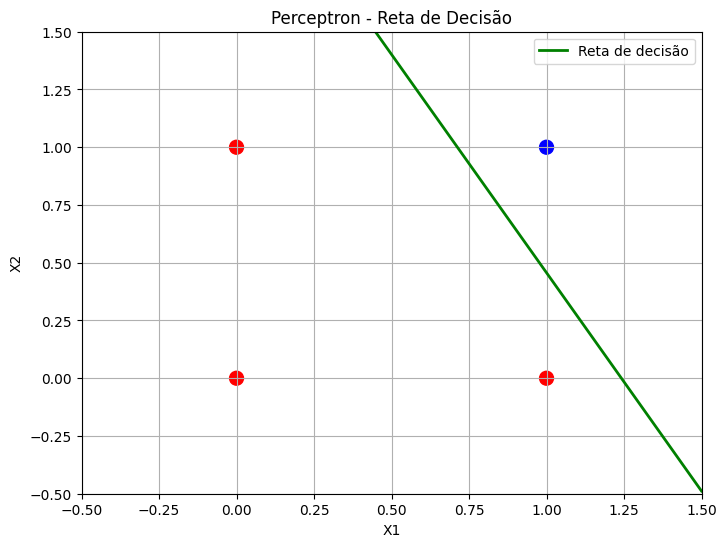

In [9]:
# Visualiza (descomente a linha abaixo para ver o gráfico)
visualizar_perceptron(perceptron, X, y)

# Resolução de desafio para simular a porta OR

In [10]:
# Dados de exemplo: porta lógica OR
# Entradas: [x1, x2], Saída esperada: y
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])  # OR

print("=== PERCEPTRON SIMPLES ===")
print("Porta lógica OR")
print("Dados de treinamento:")
for i in range(len(X)):
    print(f"Entrada: {X[i]}, Saída esperada: {y[i]}")

=== PERCEPTRON SIMPLES ===
Porta lógica OR
Dados de treinamento:
Entrada: [0 0], Saída esperada: 0
Entrada: [0 1], Saída esperada: 1
Entrada: [1 0], Saída esperada: 1
Entrada: [1 1], Saída esperada: 1


In [11]:
# Cria e treina o perceptron
perceptron = Perceptron(taxa_aprendizado=0.1, epocas=10)
perceptron.treinar(X, y)

print("\nPesos finais:", perceptron.pesos)
print("Viés final:", perceptron.vies)

Época 1: 3 ajustes
Época 2: 2 ajustes
Época 3: 1 ajustes
Época 4: 2 ajustes
Época 5: 1 ajustes
Época 6: 0 ajustes
Treinamento concluído!

Pesos finais: [0.13670815 0.11773989]
Viés final: -0.1


In [12]:
# Testa o perceptron treinado
print("\n=== TESTES ===")
for entrada in X:
    previsao = perceptron.prever(entrada)
    print(f"Entrada: {entrada} → Previsão: {previsao}")


=== TESTES ===
Entrada: [0 0] → Previsão: 0
Entrada: [0 1] → Previsão: 1
Entrada: [1 0] → Previsão: 1
Entrada: [1 1] → Previsão: 1


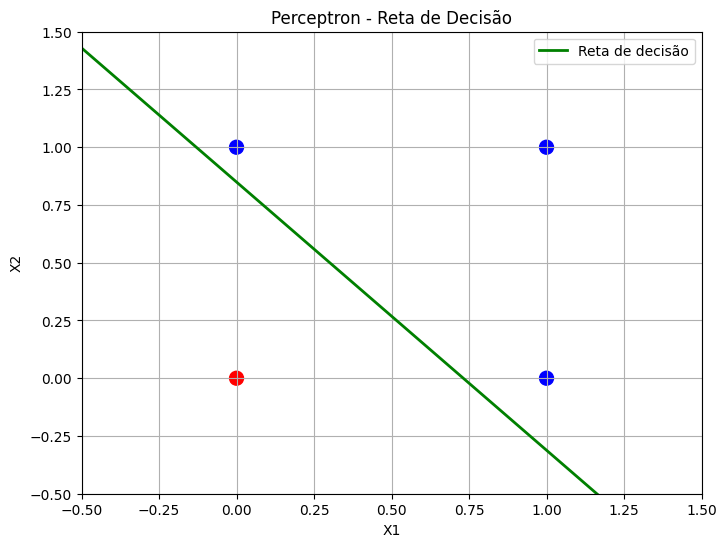

In [13]:
# Visualiza (descomente a linha abaixo para ver o gráfico)
visualizar_perceptron(perceptron, X, y)